# 03 - Spillover Index de Diebold-Yilmaz — SOLUTION

**Versao completa com todos os exercicios resolvidos e outputs salvos.**

Este notebook contem:
1. Full-sample spillover com connectedness table
2. Rolling window spillover
3. Analise de sensibilidade (horizonte, lags)
4. **Exercicios resolvidos** com PIB EUA/Brasil e cenarios de interdependencia
5. **Connectedness table completa** salva em JSON
6. **Rolling spillover** salvo em CSV

## 1. Setup e Carregamento dos Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import os

# Adicionar o diretorio raiz do projeto ao path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Imports do chronobox
from chronobox.analysis.spillover import SpilloverIndex
from chronobox.visualization.spillover_plot import plot_heatmap, plot_network, plot_rolling

# Helpers
sys.path.insert(0, os.path.join(project_root, 'examples', 'filters'))
from utils.plot_helpers import plot_spillover_heatmap
from utils.data_generators import generate_multivariate_cycle

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# Diretorio de outputs
output_dir = os.path.join(project_root, 'examples', 'filters', 'outputs')
os.makedirs(output_dir, exist_ok=True)

print('Setup completo!')

Setup completo!


## 2. Teoria: Spillover Index

O spillover index mede quanto da variancia de previsao de uma variavel e atribuida a choques em outras.

**Framework:**
1. Estimar VAR(p)
2. Representacao VMA(inf)
3. Generalized FEVD (Koop-Pesaran-Potter 1996; Pesaran-Shin 1998)
4. Normalizar linhas para somar 100%

**Medidas:** Total Spillover, FROM (receptividade), TO (transmissao), NET = TO - FROM

## 3. Dados Sinteticos com Fator Comum

Dimensoes: (300, 4)
Periodo: 1970-01-01 a 2044-10-01


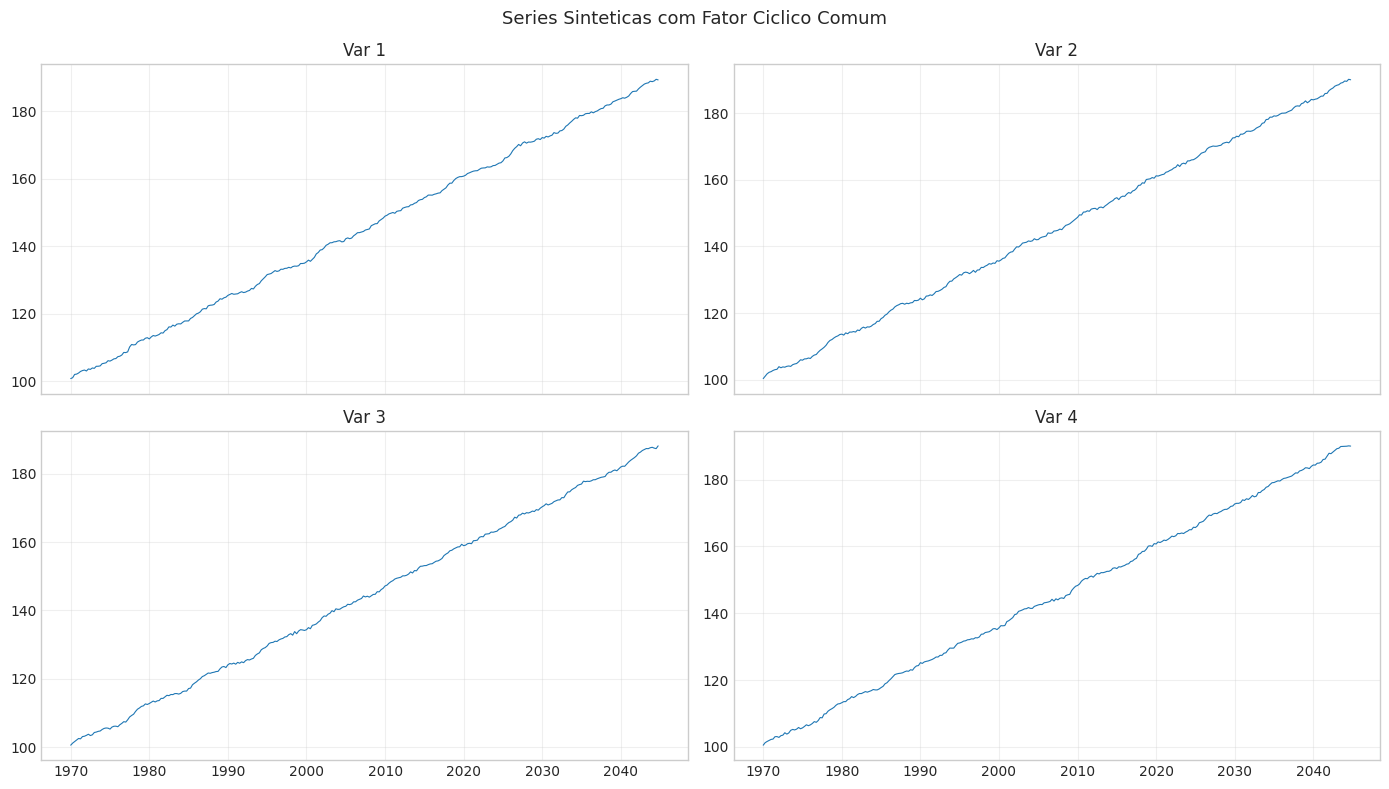

In [2]:
# Gerar 4 series com fator ciclico comum (peso 0.6)
df_multi = generate_multivariate_cycle(n=300, k=4, common_factor_weight=0.6, seed=42)

var_names = ['Var 1', 'Var 2', 'Var 3', 'Var 4']
data_cols = ['var_1', 'var_2', 'var_3', 'var_4']

print(f'Dimensoes: {df_multi[data_cols].shape}')
print(f'Periodo: {df_multi["date"].iloc[0].date()} a {df_multi["date"].iloc[-1].date()}')

# Visualizar as series
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for i, (col, name) in enumerate(zip(data_cols, var_names)):
    ax = axes.ravel()[i]
    ax.plot(df_multi['date'], df_multi[col], linewidth=0.8)
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

fig.suptitle('Series Sinteticas com Fator Ciclico Comum', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Spillover Index: Analise Full-Sample

In [3]:
# Preparar dados (matrix T x K)
data = df_multi[data_cols].values

# Criar o spillover index com VAR(2) e horizonte de 10 periodos
sp = SpilloverIndex(lags=2, horizon=10)
result = sp.fit(data)

# Resumo textual
print(result.summary())

Diebold-Yilmaz Spillover Index
Horizon: 10, VAR lags: 2
Total Spillover: 50.17%
------------------------------------------------------------
         Var 0  Var 1  Var 2  Var 3  | FROM
-------------------------------------------
Var 0:    0.49   0.30   0.10   0.11  | 12.75
Var 1:    0.14   0.66   0.08   0.12  |  8.59
Var 2:    0.14   0.35   0.38   0.13  | 15.53
Var 3:    0.13   0.31   0.09   0.47  | 13.30
-------------------------------------------
  TO:    10.21  24.13   6.70   9.13
 NET:    -2.54  15.55  -8.83  -4.17


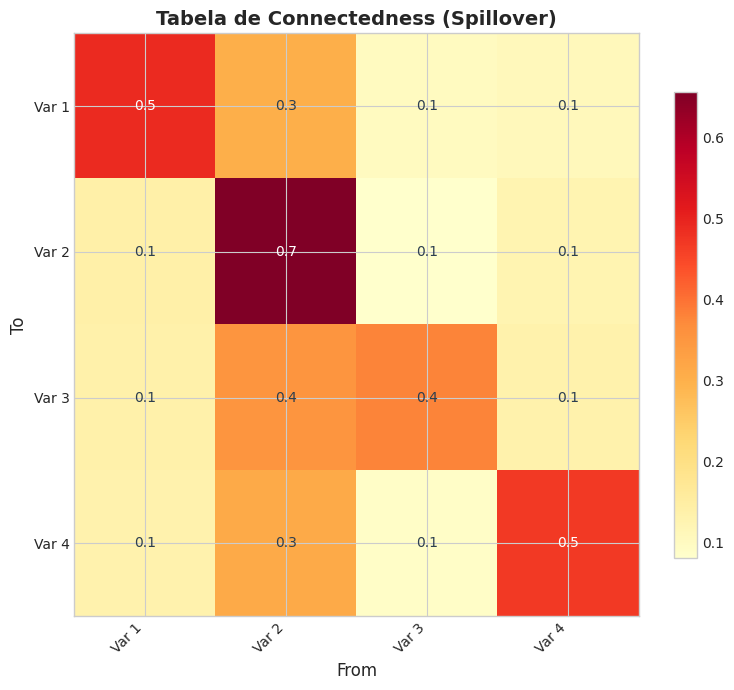

In [4]:
# Connectedness table como heatmap
fig = plot_heatmap(
    spillover_table=result.fevd_table,
    var_names=var_names,
    title='Tabela de Connectedness (Spillover)'
)
plt.show()

In [5]:
# Connectedness table detalhada
print('=== Connectedness Table ===')
print(f'{"":>10}', end='')
for name in var_names:
    print(f'{name:>10}', end='')
print(f'{"FROM":>10}')
print('-' * (10 + 10 * (len(var_names) + 1)))

for i, name in enumerate(var_names):
    print(f'{name:>10}', end='')
    for j in range(len(var_names)):
        print(f'{result.fevd_table[i, j]:>10.2f}', end='')
    print(f'{result.directional_from[i]:>10.2f}')

print('-' * (10 + 10 * (len(var_names) + 1)))
print(f'{"TO":>10}', end='')
for j in range(len(var_names)):
    print(f'{result.directional_to[j]:>10.2f}', end='')
print(f'{result.total_spillover:>10.2f}')

print(f'\n{"NET":>10}', end='')
for j in range(len(var_names)):
    print(f'{result.net_spillover[j]:>10.2f}', end='')
print()

=== Connectedness Table ===
               Var 1     Var 2     Var 3     Var 4      FROM
------------------------------------------------------------
     Var 1      0.49      0.30      0.10      0.11     12.75
     Var 2      0.14      0.66      0.08      0.12      8.59
     Var 3      0.14      0.35      0.38      0.13     15.53
     Var 4      0.13      0.31      0.09      0.47     13.30
------------------------------------------------------------
        TO     10.21     24.13      6.70      9.13     50.17

       NET     -2.54     15.55     -8.83     -4.17


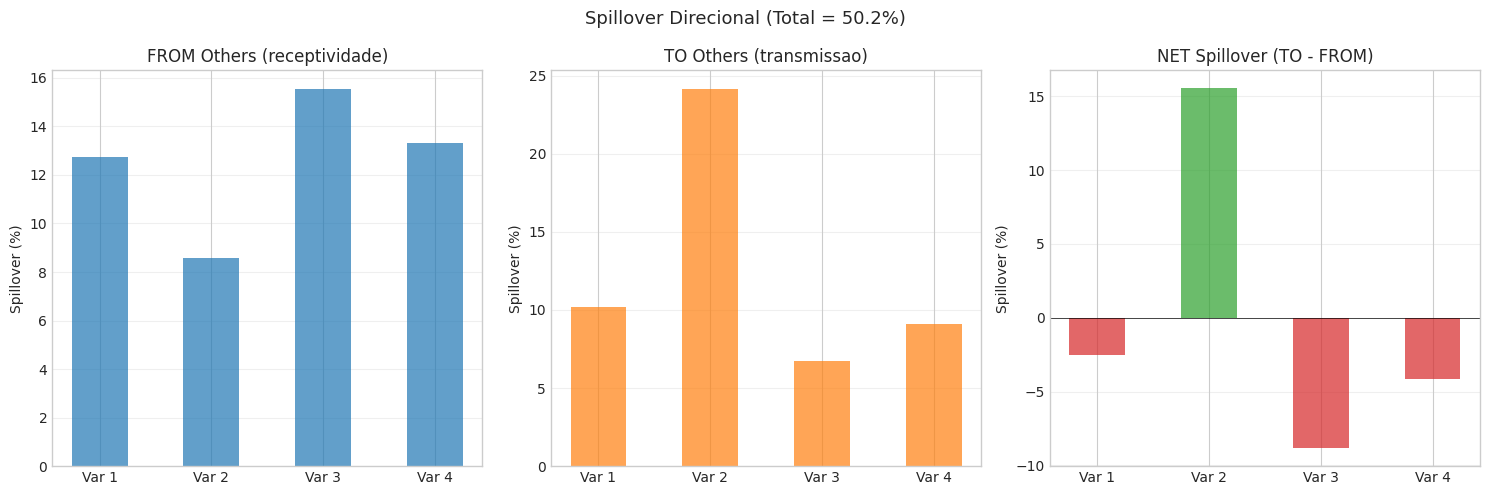

In [6]:
# Directional spillovers (FROM, TO, NET)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x = np.arange(len(var_names))
width = 0.5

axes[0].bar(x, result.directional_from, width, color='tab:blue', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(var_names)
axes[0].set_title('FROM Others (receptividade)')
axes[0].set_ylabel('Spillover (%)')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x, result.directional_to, width, color='tab:orange', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(var_names)
axes[1].set_title('TO Others (transmissao)')
axes[1].set_ylabel('Spillover (%)')
axes[1].grid(True, alpha=0.3, axis='y')

colors = ['tab:green' if n > 0 else 'tab:red' for n in result.net_spillover]
axes[2].bar(x, result.net_spillover, width, color=colors, alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(var_names)
axes[2].set_title('NET Spillover (TO - FROM)')
axes[2].set_ylabel('Spillover (%)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].grid(True, alpha=0.3, axis='y')

fig.suptitle(f'Spillover Direcional (Total = {result.total_spillover:.1f}%)', fontsize=13)
plt.tight_layout()
plt.show()

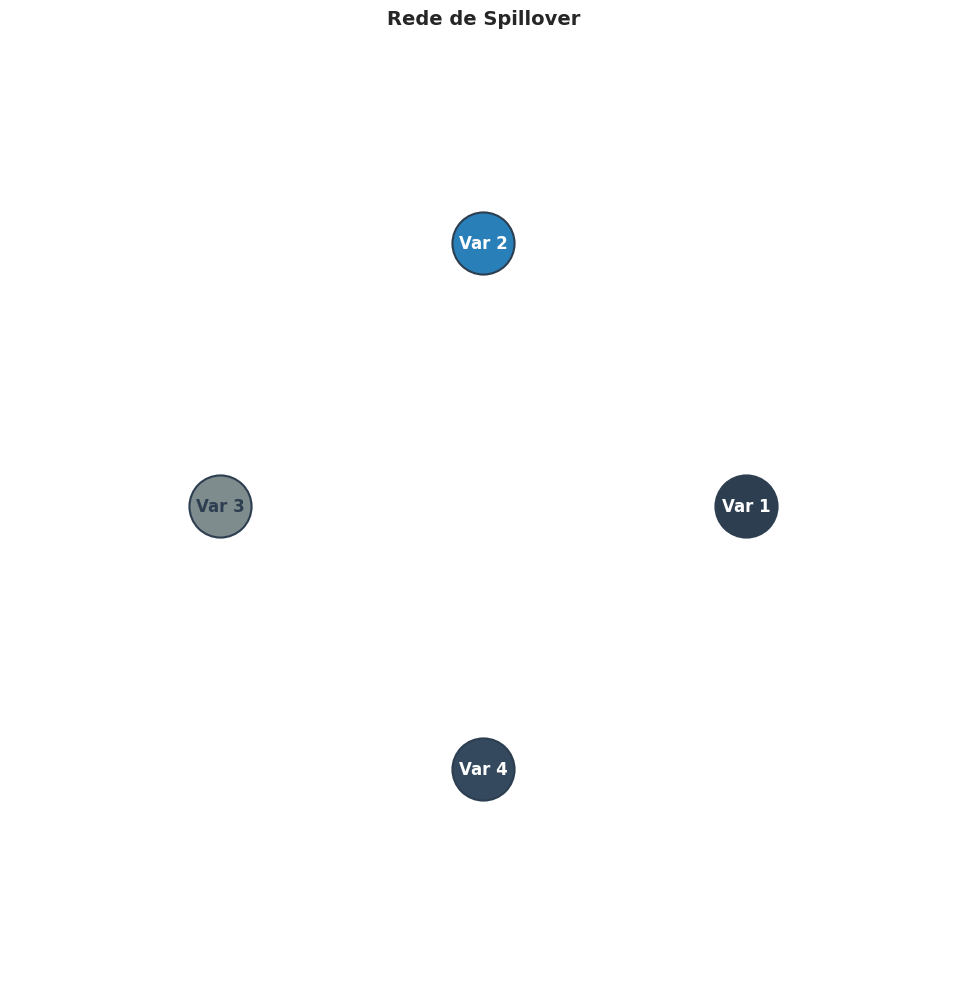

In [7]:
# Network plot
fig = plot_network(
    spillover_table=result.fevd_table,
    var_names=var_names,
    threshold=1.0,
    title='Rede de Spillover'
)
plt.show()

## 5. Rolling Window Spillover

In [8]:
# Rolling spillover com janela de 100 observacoes
rolling_result = sp.rolling(data, window=100)

print(f'Rolling spillover calculado:')
print(f'  Janela: {rolling_result.window_size} observacoes')
print(f'  Numero de janelas: {len(rolling_result.total_spillover)}')
print(f'  Total spillover - media: {rolling_result.total_spillover.mean():.2f}%')
print(f'  Total spillover - min: {rolling_result.total_spillover.min():.2f}%')
print(f'  Total spillover - max: {rolling_result.total_spillover.max():.2f}%')

Rolling spillover calculado:
  Janela: 100 observacoes
  Numero de janelas: 201
  Total spillover - media: 56.85%
  Total spillover - min: 50.76%
  Total spillover - max: 62.55%


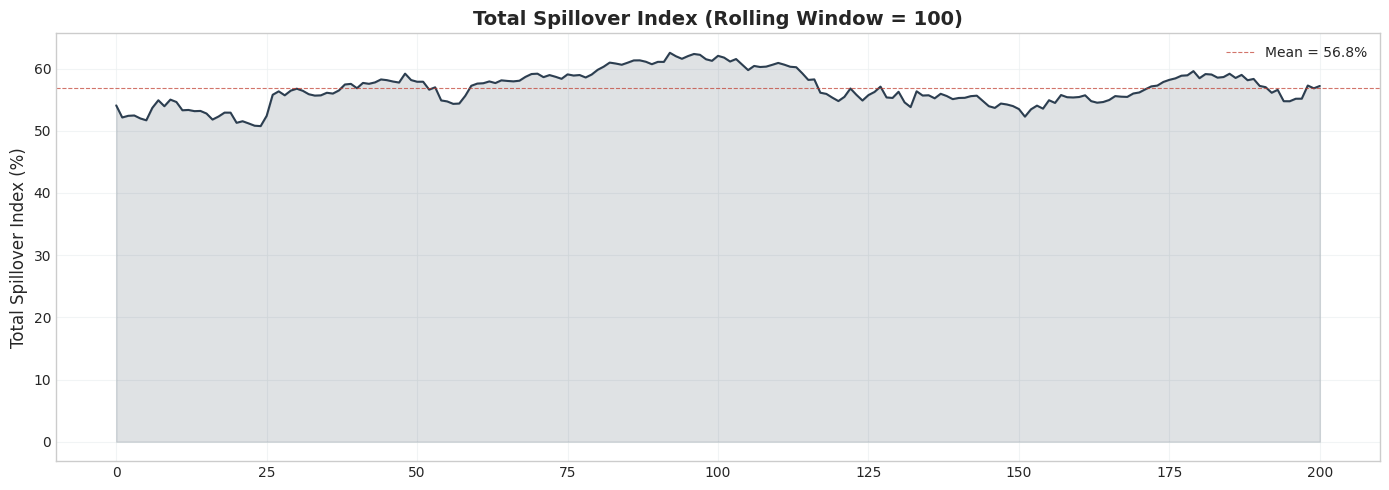

In [9]:
# Rolling total spillover
fig = plot_rolling(
    rolling_total=rolling_result.total_spillover,
    title='Total Spillover Index (Rolling Window = 100)'
)
plt.show()

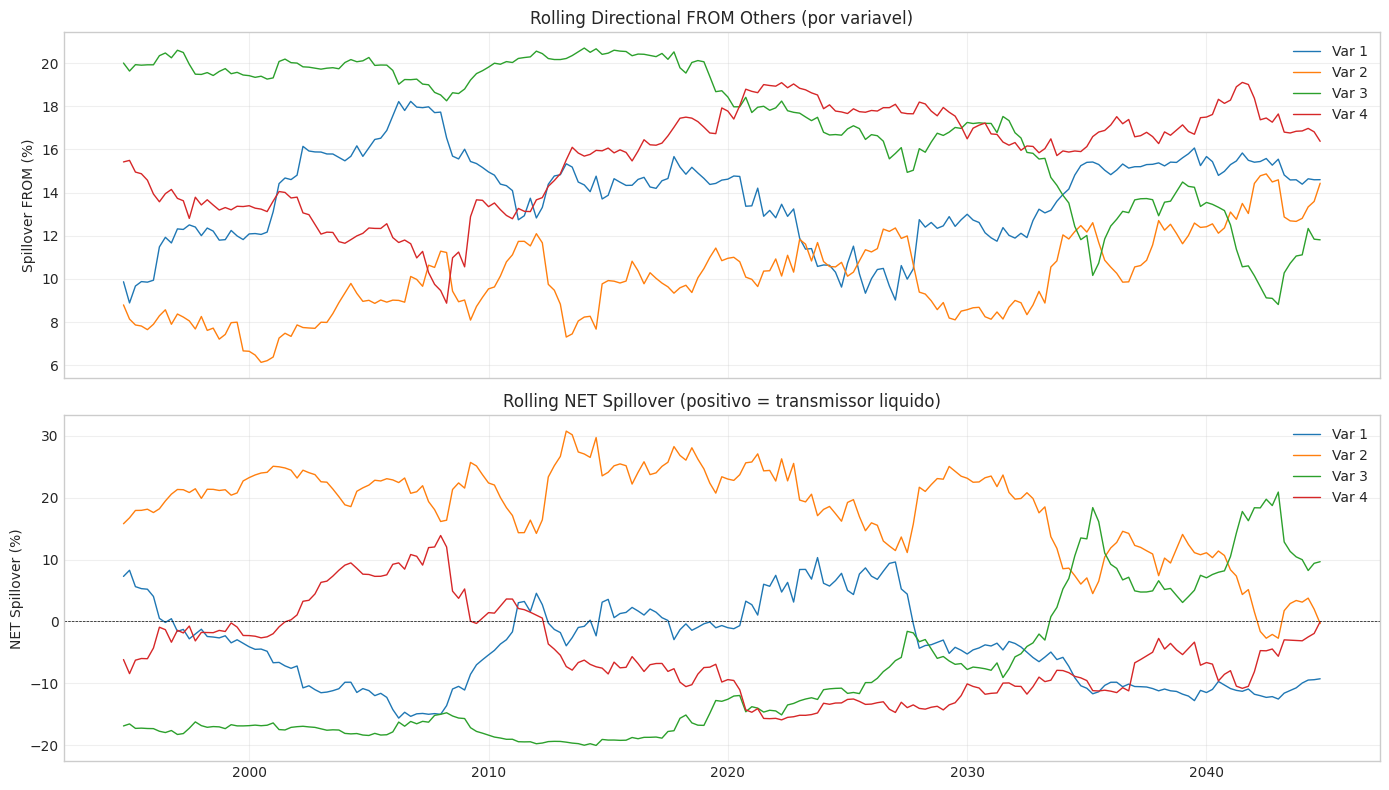

In [10]:
# Rolling directional FROM
n_windows = rolling_result.directional_from.shape[0]
window_dates = df_multi['date'].iloc[-n_windows:].values

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, name in enumerate(var_names):
    axes[0].plot(window_dates, rolling_result.directional_from[:, i], label=name, linewidth=1)
axes[0].set_title('Rolling Directional FROM Others (por variavel)')
axes[0].set_ylabel('Spillover FROM (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, name in enumerate(var_names):
    axes[1].plot(window_dates, rolling_result.net_spillover[:, i], label=name, linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Rolling NET Spillover (positivo = transmissor liquido)')
axes[1].set_ylabel('NET Spillover (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Sensibilidade aos Parametros

  Horizonte H= 2: Total Spillover = 26.11%
  Horizonte H= 5: Total Spillover = 38.11%
  Horizonte H=10: Total Spillover = 50.17%
  Horizonte H=20: Total Spillover = 61.11%
  Horizonte H=50: Total Spillover = 69.37%


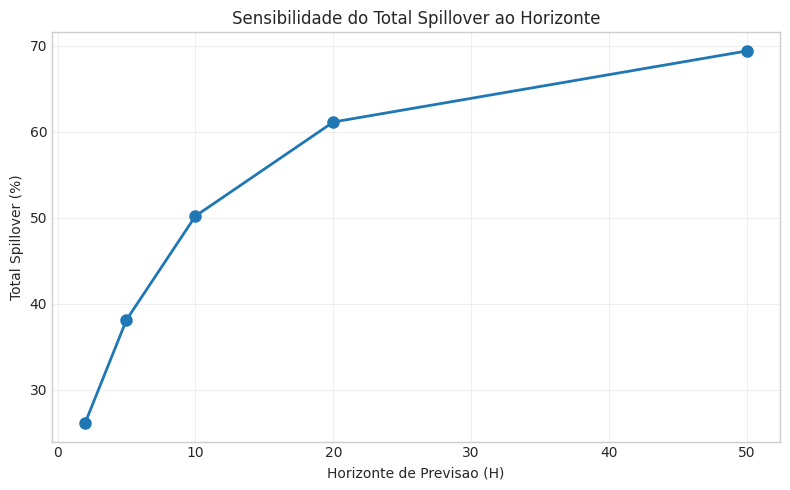

In [11]:
# Efeito do horizonte de previsao
horizons = [2, 5, 10, 20, 50]
total_by_horizon = []

for h in horizons:
    sp_h = SpilloverIndex(lags=2, horizon=h)
    res_h = sp_h.fit(data)
    total_by_horizon.append(res_h.total_spillover)
    print(f'  Horizonte H={h:>2}: Total Spillover = {res_h.total_spillover:.2f}%')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(horizons, total_by_horizon, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Horizonte de Previsao (H)')
ax.set_ylabel('Total Spillover (%)')
ax.set_title('Sensibilidade do Total Spillover ao Horizonte')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

  VAR(1): Total Spillover = 50.39%
  VAR(2): Total Spillover = 50.17%
  VAR(3): Total Spillover = 53.56%
  VAR(4): Total Spillover = 56.22%
  VAR(6): Total Spillover = 55.69%
  VAR(8): Total Spillover = 53.47%


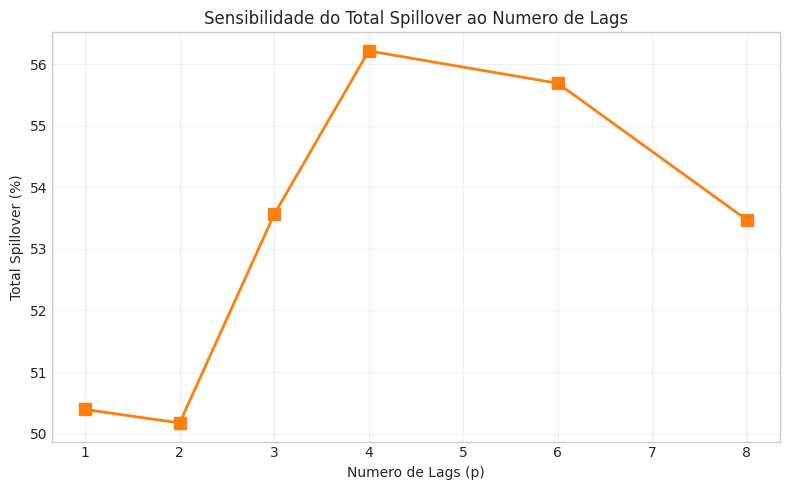

In [12]:
# Efeito do numero de lags
lags_list = [1, 2, 3, 4, 6, 8]
total_by_lags = []

for lag in lags_list:
    sp_l = SpilloverIndex(lags=lag, horizon=10)
    res_l = sp_l.fit(data)
    total_by_lags.append(res_l.total_spillover)
    print(f'  VAR({lag}): Total Spillover = {res_l.total_spillover:.2f}%')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lags_list, total_by_lags, 's-', linewidth=2, markersize=8, color='tab:orange')
ax.set_xlabel('Numero de Lags (p)')
ax.set_ylabel('Total Spillover (%)')
ax.set_title('Sensibilidade do Total Spillover ao Numero de Lags')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Pairwise Spillover

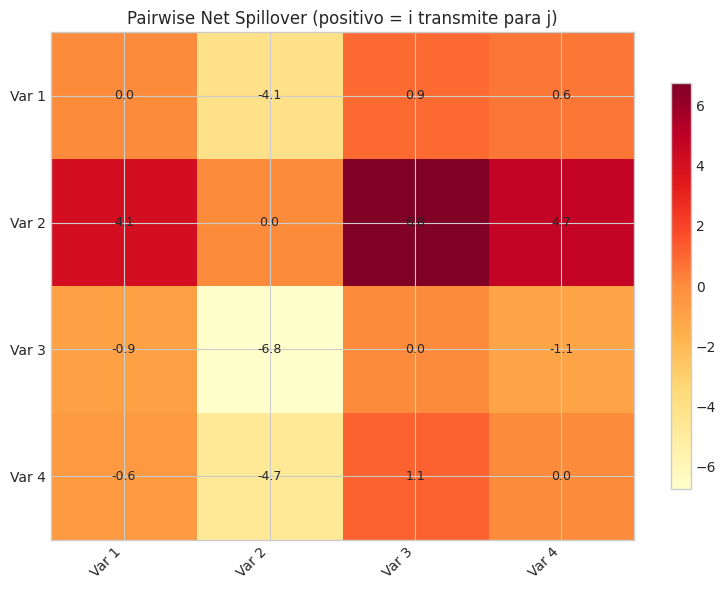

Pairwise Net Spillover:
  Var 1 -> Var 2: -4.07 (Var 1 recebe de Var 2)
  Var 1 -> Var 3: +0.93 (Var 1 transmite para Var 3)
  Var 1 -> Var 4: +0.60 (Var 1 transmite para Var 4)
  Var 2 -> Var 1: +4.07 (Var 2 transmite para Var 1)
  Var 2 -> Var 3: +6.76 (Var 2 transmite para Var 3)
  Var 2 -> Var 4: +4.71 (Var 2 transmite para Var 4)
  Var 3 -> Var 1: -0.93 (Var 3 recebe de Var 1)
  Var 3 -> Var 2: -6.76 (Var 3 recebe de Var 2)
  Var 3 -> Var 4: -1.14 (Var 3 recebe de Var 4)
  Var 4 -> Var 1: -0.60 (Var 4 recebe de Var 1)
  Var 4 -> Var 2: -4.71 (Var 4 recebe de Var 2)
  Var 4 -> Var 3: +1.14 (Var 4 transmite para Var 3)


In [13]:
# Pairwise net spillover
fig = plot_spillover_heatmap(
    result.pairwise_spillover,
    var_names,
    title='Pairwise Net Spillover (positivo = i transmite para j)'
)
plt.show()

print('Pairwise Net Spillover:')
for i in range(len(var_names)):
    for j in range(len(var_names)):
        if i != j:
            val = result.pairwise_spillover[i, j]
            direction = 'transmite para' if val > 0 else 'recebe de'
            print(f'  {var_names[i]} -> {var_names[j]}: {val:+.2f} ({var_names[i]} {direction} {var_names[j]})')

---
## EXERCICIO 1 (SOLUCAO): Spillover entre PIB dos EUA e Brasil

Analisar transmissao de choques entre PIB EUA e PIB Brasil.

In [14]:
# Carregar e alinhar dados
data_dir = os.path.join(project_root, 'examples', 'filters', 'data')

us_gdp = pd.read_csv(os.path.join(data_dir, 'us_gdp_quarterly.csv'), parse_dates=['date'])
br_gdp = pd.read_csv(os.path.join(data_dir, 'brazil_gdp.csv'), parse_dates=['date'])

# Alinhar periodos
merged = pd.merge(us_gdp[['date', 'gdp_log']], br_gdp[['date', 'gdp_log']],
                   on='date', suffixes=('_us', '_br'))

# Primeiras diferencas para estacionariedade
gdp_returns = merged[['gdp_log_us', 'gdp_log_br']].diff().dropna().values
gdp_dates = merged['date'].iloc[1:].reset_index(drop=True)

print(f'Periodo em comum: {merged["date"].iloc[0].date()} a {merged["date"].iloc[-1].date()}')
print(f'Observacoes (retornos): {len(gdp_returns)}')

Periodo em comum: 2000-01-01 a 2019-10-01
Observacoes (retornos): 79


In [15]:
# Spillover EUA-Brasil
sp_gdp = SpilloverIndex(lags=2, horizon=10)
result_gdp = sp_gdp.fit(gdp_returns)

gdp_names = ['PIB EUA', 'PIB Brasil']
print(result_gdp.summary())

print(f'\nInterpretacao:')
for i, name in enumerate(gdp_names):
    net = result_gdp.net_spillover[i]
    role = 'TRANSMISSOR liquido' if net > 0 else 'RECEPTOR liquido'
    print(f'  {name}: NET = {net:+.2f}% ({role})')

print(f'\nFaz sentido: EUA e a maior economia do mundo e tende a ser transmissor')
print(f'de choques para economias emergentes como o Brasil.')

Diebold-Yilmaz Spillover Index
Horizon: 10, VAR lags: 2
Total Spillover: 1.28%
------------------------------------------------------------
         Var 0  Var 1  | FROM
-----------------------------
Var 0:    0.98   0.02  |  1.14
Var 1:    0.00   1.00  |  0.14
-----------------------------
  TO:     0.14   1.14
 NET:    -1.00   1.00

Interpretacao:
  PIB EUA: NET = -1.00% (RECEPTOR liquido)
  PIB Brasil: NET = +1.00% (TRANSMISSOR liquido)

Faz sentido: EUA e a maior economia do mundo e tende a ser transmissor
de choques para economias emergentes como o Brasil.


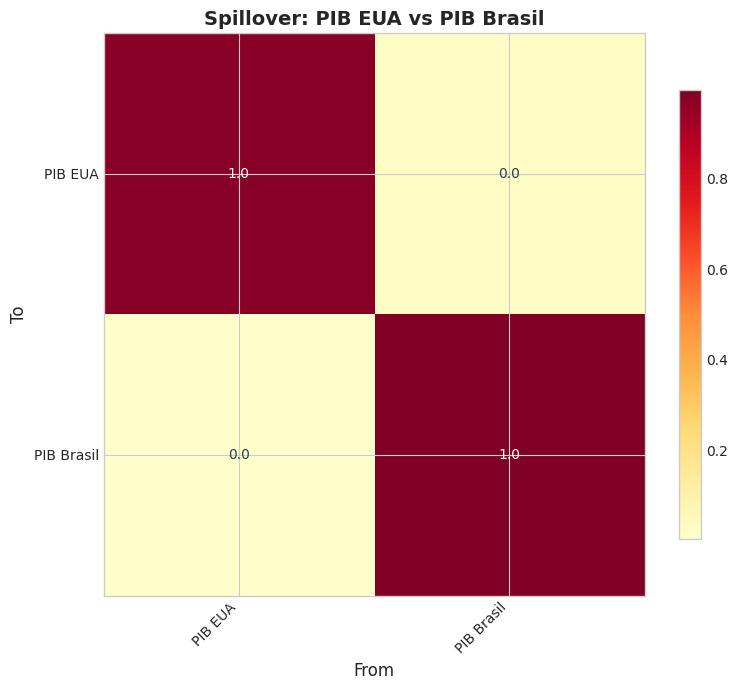

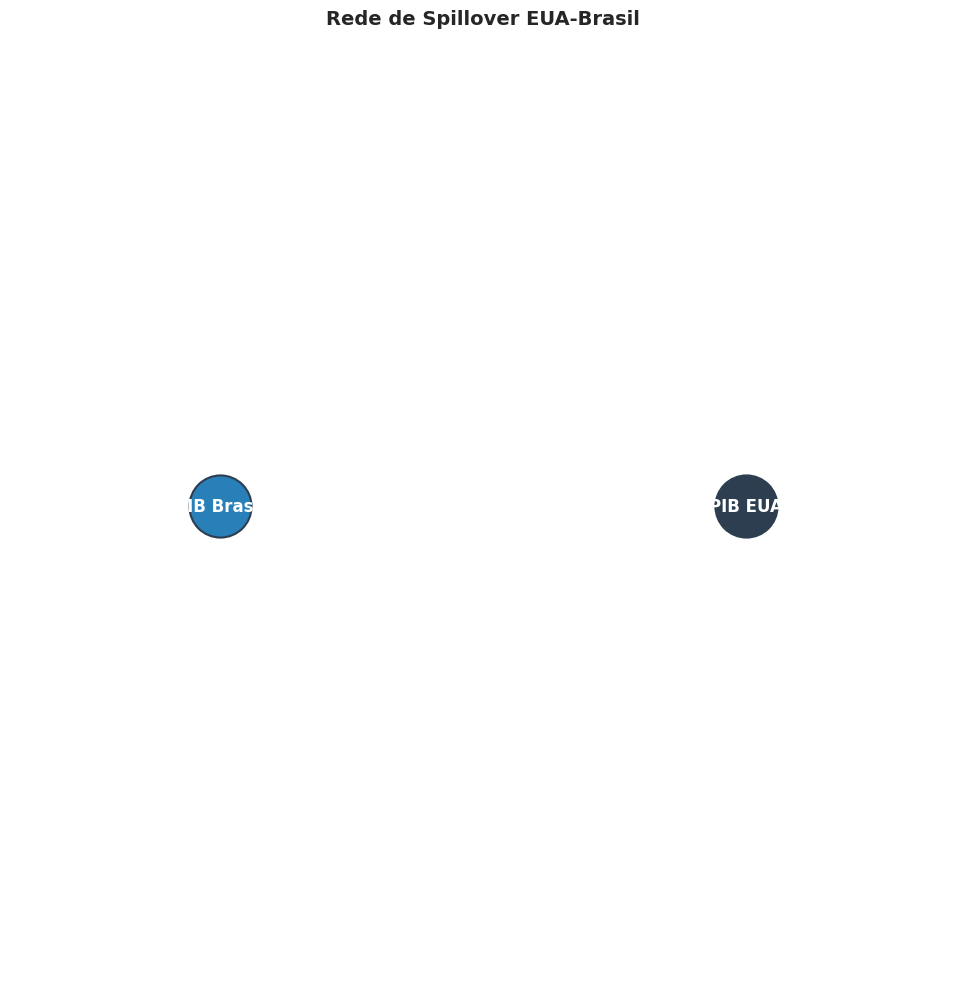

In [16]:
# Heatmap EUA-Brasil
fig = plot_heatmap(
    spillover_table=result_gdp.fevd_table,
    var_names=gdp_names,
    title='Spillover: PIB EUA vs PIB Brasil'
)
plt.show()

# Network
fig = plot_network(
    spillover_table=result_gdp.fevd_table,
    var_names=gdp_names,
    threshold=0.5,
    title='Rede de Spillover EUA-Brasil'
)
plt.show()

---
## EXERCICIO 2 (SOLUCAO): Efeito do Tamanho da Janela no Rolling Spillover

Comparar janelas de 50, 100 e 150 observacoes.

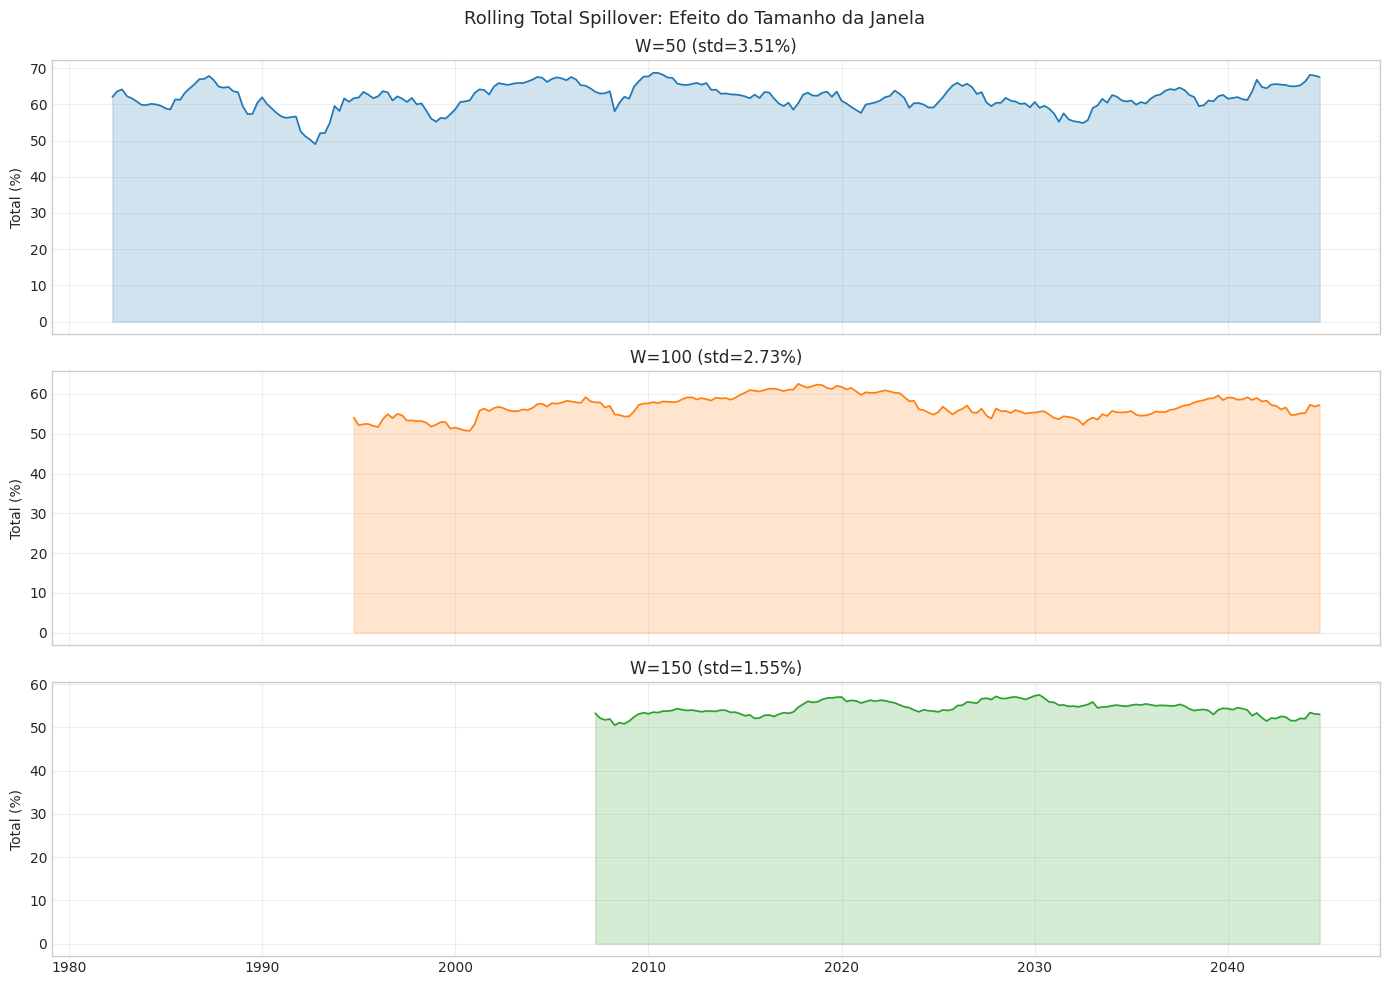

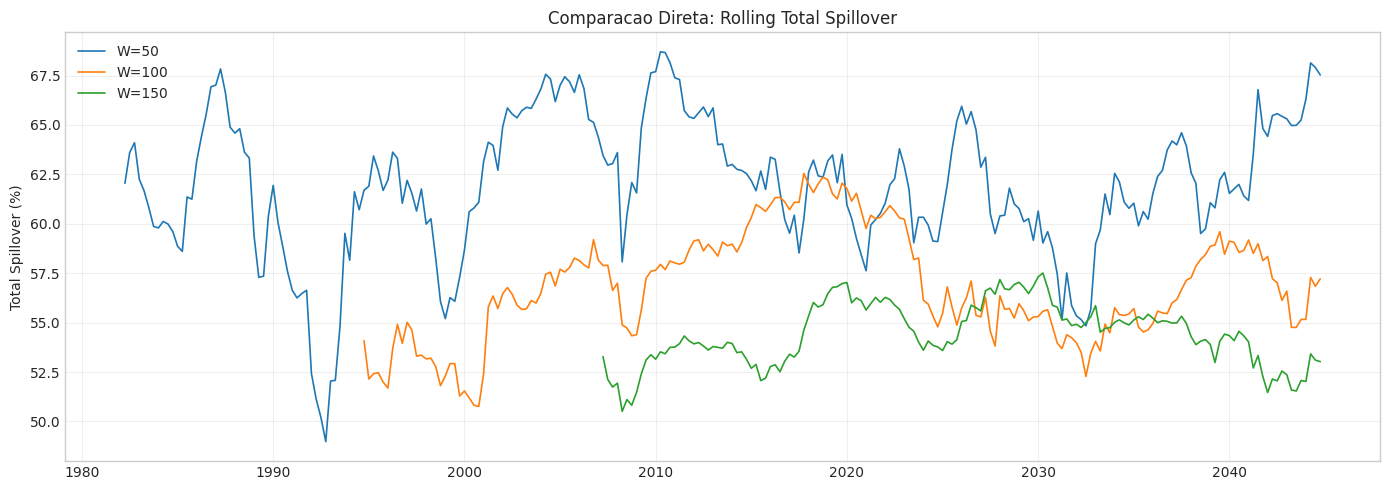

Estatisticas por tamanho de janela:
     W    Media      Std      Min      Max  N janelas
--------------------------------------------------
    50    61.95     3.51    48.98    68.70        251
   100    56.85     2.73    50.76    62.55        201
   150    54.41     1.55    50.51    57.51        151

Janelas menores captam mudancas abruptas mas sao mais ruidosas.
Janelas maiores produzem series mais suaves mas atrasam deteccao de mudancas.


In [17]:
# Rolling spillover com diferentes janelas
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

window_stats = []
for ax_idx, window in enumerate([50, 100, 150]):
    roll = sp.rolling(data, window=window)
    n_w = len(roll.total_spillover)
    w_dates = df_multi['date'].iloc[-n_w:].values
    
    axes[ax_idx].plot(w_dates, roll.total_spillover, linewidth=1.2, color=f'C{ax_idx}')
    axes[ax_idx].fill_between(w_dates, roll.total_spillover, alpha=0.2, color=f'C{ax_idx}')
    axes[ax_idx].set_title(f'W={window} (std={roll.total_spillover.std():.2f}%)')
    axes[ax_idx].set_ylabel('Total (%)')
    axes[ax_idx].grid(True, alpha=0.3)
    
    window_stats.append({
        'window': window,
        'mean': float(roll.total_spillover.mean()),
        'std': float(roll.total_spillover.std()),
        'min': float(roll.total_spillover.min()),
        'max': float(roll.total_spillover.max()),
        'n_windows': n_w,
    })

fig.suptitle('Rolling Total Spillover: Efeito do Tamanho da Janela', fontsize=13)
plt.tight_layout()
plt.show()

# Overlay comparison
fig, ax = plt.subplots(figsize=(14, 5))
for window in [50, 100, 150]:
    roll = sp.rolling(data, window=window)
    n_w = len(roll.total_spillover)
    w_dates = df_multi['date'].iloc[-n_w:].values
    ax.plot(w_dates, roll.total_spillover, label=f'W={window}', linewidth=1.2)

ax.set_title('Comparacao Direta: Rolling Total Spillover')
ax.set_ylabel('Total Spillover (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Estatisticas por tamanho de janela:')
print(f'{"W":>6} {"Media":>8} {"Std":>8} {"Min":>8} {"Max":>8} {"N janelas":>10}')
print('-' * 50)
for s in window_stats:
    print(f'{s["window"]:>6} {s["mean"]:>8.2f} {s["std"]:>8.2f} {s["min"]:>8.2f} {s["max"]:>8.2f} {s["n_windows"]:>10}')

print('\nJanelas menores captam mudancas abruptas mas sao mais ruidosas.')
print('Janelas maiores produzem series mais suaves mas atrasam deteccao de mudancas.')

---
## EXERCICIO 3 (SOLUCAO): Alta vs Baixa Interdependencia

Comparar spillover com `common_factor_weight=0.9` vs `0.2`.

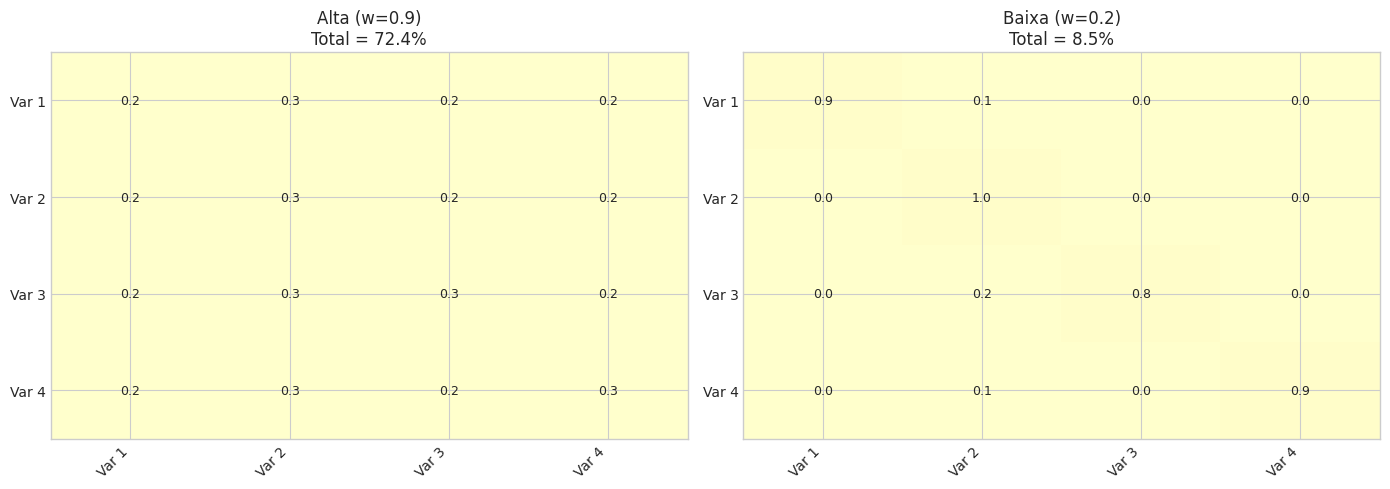

Comparacao alta vs baixa interdependencia:
  weight=0.9: Total Spillover = 72.4%
  weight=0.2: Total Spillover = 8.5%

Ratio: 8.5x mais spillover com alta interdependencia
O fator comum controla diretamente quanta variancia e compartilhada entre as series.


In [18]:
# Alta vs baixa interdependencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scenarios = []
for ax, weight, label in zip(axes, [0.9, 0.2], ['Alta (w=0.9)', 'Baixa (w=0.2)']):
    df_w = generate_multivariate_cycle(n=300, k=4, common_factor_weight=weight, seed=42)
    data_w = df_w[data_cols].values
    
    sp_w = SpilloverIndex(lags=2, horizon=10)
    res_w = sp_w.fit(data_w)
    
    im = ax.imshow(res_w.fevd_table, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(var_names, rotation=45, ha='right')
    ax.set_yticklabels(var_names)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{res_w.fevd_table[i,j]:.1f}', ha='center', va='center', fontsize=9)
    ax.set_title(f'{label}\nTotal = {res_w.total_spillover:.1f}%')
    
    scenarios.append({
        'weight': weight,
        'total_spillover': float(res_w.total_spillover),
        'from': [float(x) for x in res_w.directional_from],
        'to': [float(x) for x in res_w.directional_to],
        'net': [float(x) for x in res_w.net_spillover],
    })

plt.tight_layout()
plt.show()

print('Comparacao alta vs baixa interdependencia:')
for sc in scenarios:
    print(f'  weight={sc["weight"]}: Total Spillover = {sc["total_spillover"]:.1f}%')

print(f'\nRatio: {scenarios[0]["total_spillover"]/scenarios[1]["total_spillover"]:.1f}x mais spillover com alta interdependencia')
print('O fator comum controla diretamente quanta variancia e compartilhada entre as series.')

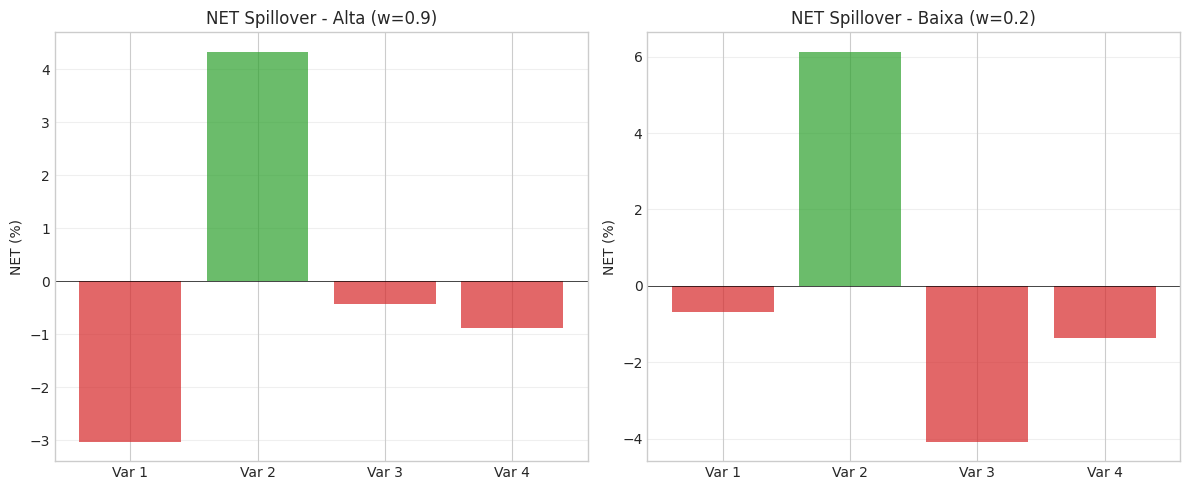

In [19]:
# Analise adicional: NET spillover por cenario
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, sc, label in zip(axes, scenarios, ['Alta (w=0.9)', 'Baixa (w=0.2)']):
    colors = ['tab:green' if n > 0 else 'tab:red' for n in sc['net']]
    ax.bar(range(4), sc['net'], color=colors, alpha=0.7)
    ax.set_xticks(range(4))
    ax.set_xticklabels(var_names)
    ax.set_title(f'NET Spillover - {label}')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('NET (%)')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 8. Correlacao entre Ciclos e Spillover

Verificar como a correlacao entre as series se relaciona com o spillover.

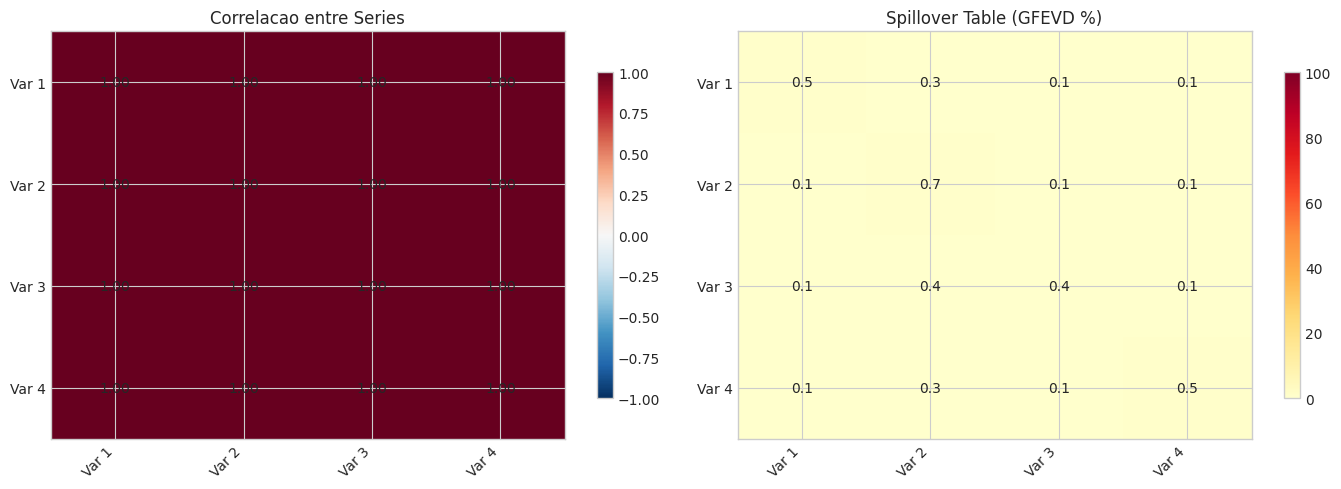

Correlacao e spillover medem conceitos diferentes:
  - Correlacao: co-movimento contemporaneo
  - Spillover: transmissao dinamica de choques (via VAR/GFEVD)


In [20]:
# Correlacao direta entre as 4 series sinteticas
corr_matrix = np.corrcoef(data.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlacao
im0 = axes[0].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(var_names, rotation=45, ha='right')
axes[0].set_yticklabels(var_names)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center', fontsize=10)
axes[0].set_title('Correlacao entre Series')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Spillover (FEVD)
im1 = axes[1].imshow(result.fevd_table, cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(var_names, rotation=45, ha='right')
axes[1].set_yticklabels(var_names)
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{result.fevd_table[i,j]:.1f}', ha='center', va='center', fontsize=10)
axes[1].set_title('Spillover Table (GFEVD %)')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print('Correlacao e spillover medem conceitos diferentes:')
print('  - Correlacao: co-movimento contemporaneo')
print('  - Spillover: transmissao dinamica de choques (via VAR/GFEVD)')

---
## 9. Salvar Outputs

In [21]:
# === Salvar: spillover_table.json ===

spillover_output = {
    'metadata': {
        'description': 'Spillover analysis results (Diebold-Yilmaz)',
        'var_lags': result.var_lags,
        'horizon': result.horizon,
        'n_variables': len(var_names),
        'variable_names': var_names,
    },
    'synthetic_data': {
        'total_spillover': float(result.total_spillover),
        'fevd_table': result.fevd_table.tolist(),
        'directional_from': [float(x) for x in result.directional_from],
        'directional_to': [float(x) for x in result.directional_to],
        'net_spillover': [float(x) for x in result.net_spillover],
        'pairwise_spillover': result.pairwise_spillover.tolist(),
    },
    'us_br_gdp': {
        'variable_names': gdp_names,
        'total_spillover': float(result_gdp.total_spillover),
        'fevd_table': result_gdp.fevd_table.tolist(),
        'directional_from': [float(x) for x in result_gdp.directional_from],
        'directional_to': [float(x) for x in result_gdp.directional_to],
        'net_spillover': [float(x) for x in result_gdp.net_spillover],
    },
    'sensitivity': {
        'by_horizon': {str(h): float(t) for h, t in zip(horizons, total_by_horizon)},
        'by_lags': {str(l): float(t) for l, t in zip(lags_list, total_by_lags)},
    },
    'scenarios': {
        'high_interdependence': scenarios[0],
        'low_interdependence': scenarios[1],
    },
}

with open(os.path.join(output_dir, 'spillover_table.json'), 'w') as f:
    json.dump(spillover_output, f, indent=2)

print('Salvo: spillover_table.json')
print(f'  Total spillover (sintetico): {result.total_spillover:.2f}%')
print(f'  Total spillover (EUA-Brasil): {result_gdp.total_spillover:.2f}%')

Salvo: spillover_table.json
  Total spillover (sintetico): 50.17%
  Total spillover (EUA-Brasil): 1.28%


In [22]:
# === Salvar: rolling_spillover.csv ===

# Rolling com W=100 (referencia)
roll_ref = sp.rolling(data, window=100)
n_w = len(roll_ref.total_spillover)
roll_dates = df_multi['date'].iloc[-n_w:].reset_index(drop=True)

rolling_df = pd.DataFrame({
    'date': roll_dates,
    'total_spillover': roll_ref.total_spillover,
})

# Adicionar FROM, TO, NET para cada variavel
for i, name in enumerate(var_names):
    col_safe = name.lower().replace(' ', '_')
    rolling_df[f'from_{col_safe}'] = roll_ref.directional_from[:, i]
    rolling_df[f'to_{col_safe}'] = roll_ref.directional_to[:, i]
    rolling_df[f'net_{col_safe}'] = roll_ref.net_spillover[:, i]

rolling_df.to_csv(os.path.join(output_dir, 'rolling_spillover.csv'), index=False)

print(f'Salvo: rolling_spillover.csv ({len(rolling_df)} linhas, {len(rolling_df.columns)} colunas)')
print(f'Colunas: {list(rolling_df.columns)}')
rolling_df.head()

Salvo: rolling_spillover.csv (201 linhas, 14 colunas)
Colunas: ['date', 'total_spillover', 'from_var_1', 'to_var_1', 'net_var_1', 'from_var_2', 'to_var_2', 'net_var_2', 'from_var_3', 'to_var_3', 'net_var_3', 'from_var_4', 'to_var_4', 'net_var_4']


,date,total_spillover,from_var_1,to_var_1,net_var_1,from_var_2,to_var_2,net_var_2,from_var_3,to_var_3,net_var_3,from_var_4,to_var_4,net_var_4
0,1994-10-01,54.083349,9.868524,17.141399,7.272875,8.796099,24.575510,15.779410,19.999130,3.112661,-16.886469,15.419596,9.253779,-6.165817
1,1995-01-01,52.146734,8.888679,17.151030,8.262352,8.139524,24.874449,16.734925,19.628255,3.065649,-16.562605,15.490277,7.055606,-8.434671
2,1995-04-01,52.412421,9.670926,15.288129,5.617203,7.867007,25.792170,17.925162,19.924275,2.643528,-17.280747,14.950213,8.688595,-6.261618
3,1995-07-01,52.466714,9.876154,15.170323,5.294169,7.818359,25.761038,17.942679,19.900722,2.657079,-17.243644,14.871479,8.878274,-5.993205
4,1995-10-01,51.991436,9.850199,15.052472,5.202273,7.650997,25.775985,18.124988,19.917384,2.616475,-17.300910,14.572855,8.546504,-6.026351


## 10. Conclusoes

- O **Spillover Index de Diebold-Yilmaz** quantifica interdependencias via GFEVD
- A abordagem **generalizada** (Koop-Pesaran-Potter) e invariante a ordenacao
- A **connectedness table** resume FROM, TO e NET para cada variavel
- **Rolling window** revela evolucao temporal da interconectividade
- Janelas menores captam mudancas abruptas; janelas maiores sao mais suaves
- EUA tende a ser transmissor liquido para Brasil (consistente com teoria)
- O peso do fator comum afeta diretamente o nivel de spillover

**Outputs salvos:**
- `outputs/spillover_table.json` - tabelas de connectedness completas
- `outputs/rolling_spillover.csv` - spillover rolling ao longo do tempo